# 04 — Visualization & Insights

Create charts and summarize business insights.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

notebook_dir = Path.cwd()
csv_candidates = [
    notebook_dir / "Data/shopsy_db/shopsy_kitchen_products_cleaned.csv",
    notebook_dir.parent / "Data/shopsy_db/shopsy_kitchen_products_cleaned.csv",
    Path("Data/shopsy_db/shopsy_kitchen_products_cleaned.csv")
]
csv_path = next((path for path in csv_candidates if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError("Cleaned CSV not found in the Data/shopsy_db folder.")

df = pd.read_csv(csv_path)
for column in ["Price", "Discount", "Rating", "Reviews"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["Brand"] = df["Brand"].fillna("Unknown")
df["Material"] = df["Material"].fillna("Unknown")
df["Product_Name"] = df["Product_Name"].fillna("Unknown")

sns.set_theme(style="whitegrid", palette="deep")
print(f"Loaded {len(df):,} products from {csv_path}.")
display(df.head())

Loaded 30 products from d:\DS\Data engineering courses\DE\Project\shopsy_home_kitchen_project\Data\shopsy_db\shopsy_kitchen_products_cleaned.csv.


,Product_Name,Price,Discount,Rating,Reviews,Brand,Capacity,Material,Product_URL
0,VASOYA Pack of 1 Plastic Fridge Container - 27...,161,86,4.0,25.0,VASOYA,"2700 ml, 1500 ml, 500 ml",Plastic,https://www.shopsy.in/vasoya-pack-1-plastic-fr...
1,AneriDEALS Pack of 24 Plastic Grocery Containe...,423,78,4.1,34.0,AneriDEALS,"250 ml, 350 ml, 650 ml, 1200 ml, 1000 ml",Plastic,https://www.shopsy.in/anerideals-pack-24-plast...
2,BELIZZI Pack of 6 Plastic Fridge Container - 1...,257,74,4.1,272.0,BELIZZI,"1500 ml, 500 ml, 1000 ml",Plastic,https://www.shopsy.in/belizzi-pack-6-plastic-f...
3,KIKANII Pack of 12 Plastic Grocery Container -...,351,64,3.4,NaN,KIKANII,500 ml,Plastic,https://www.shopsy.in/kikanii-pack-12-plastic-...
4,COSY HOME MAKE IT EASY Pack of 1 Plastic Egg C...,158,80,3.8,12.0,COSY HOME MAKE IT EASY,NaN,"Plastic, Silicone, Wood",https://www.shopsy.in/cosy-home-make-easy-pack...


In [ ]:
top = df.sort_values(["Rating", "Reviews"], ascending=False).head(5)
print("Top-rated products:")
display(top[["Product_Name", "Brand", "Price", "Rating", "Reviews"]])

print("\nKey insights:")
print(f"- Average price: INR {df['Price'].mean():.2f}")
print(f"- Average rating: {df['Rating'].mean():.2f} / 5")
print(f"- Average discount: {df['Discount'].mean():.2f}%")
print(f"- Most reviewed product: {df.loc[df['Reviews'].idxmax(), 'Product_Name']}")

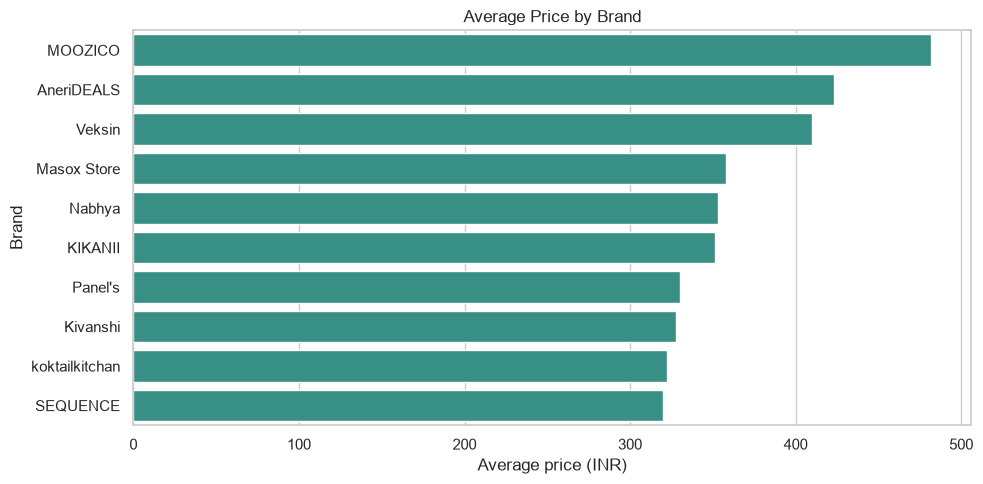

In [2]:
# Chart 1: Average price by brand
brand_price = (
    df.groupby("Brand", as_index=False)["Price"]
    .mean()
    .sort_values("Price", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_price, x="Price", y="Brand", color="#2a9d8f")
plt.title("Average Price by Brand")
plt.xlabel("Average price (INR)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

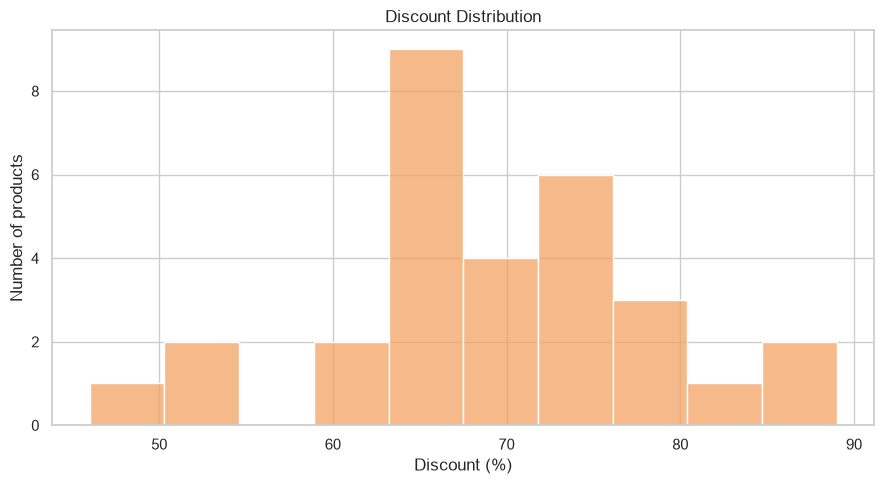

In [3]:
# Chart 2: Discount distribution
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Discount", bins=10, color="#f4a261", edgecolor="white")
plt.title("Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()

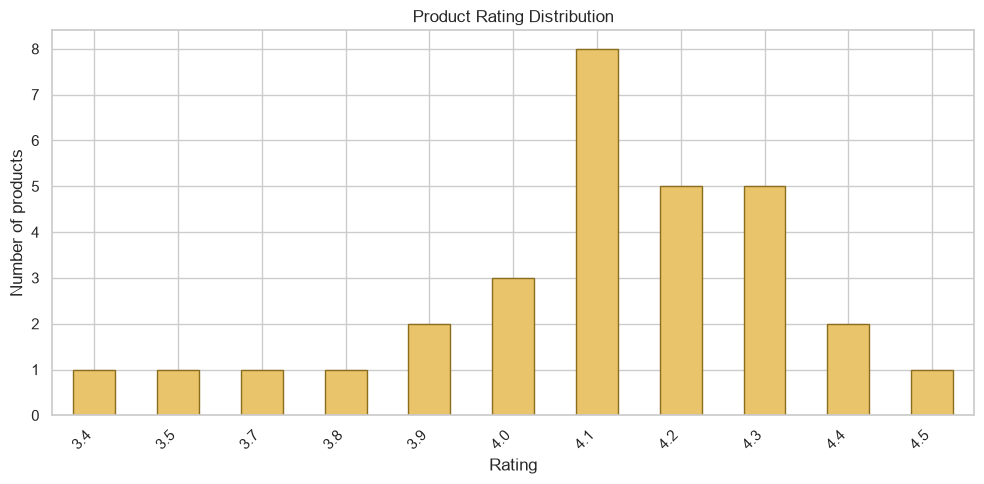

In [5]:
# Chart 3: Rating distribution
rating_counts = df["Rating"].round(1).value_counts().sort_index()
plt.figure(figsize=(10, 5))
rating_counts.plot(kind="bar", color="#e9c46a", edgecolor="#8a6d1d")
plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

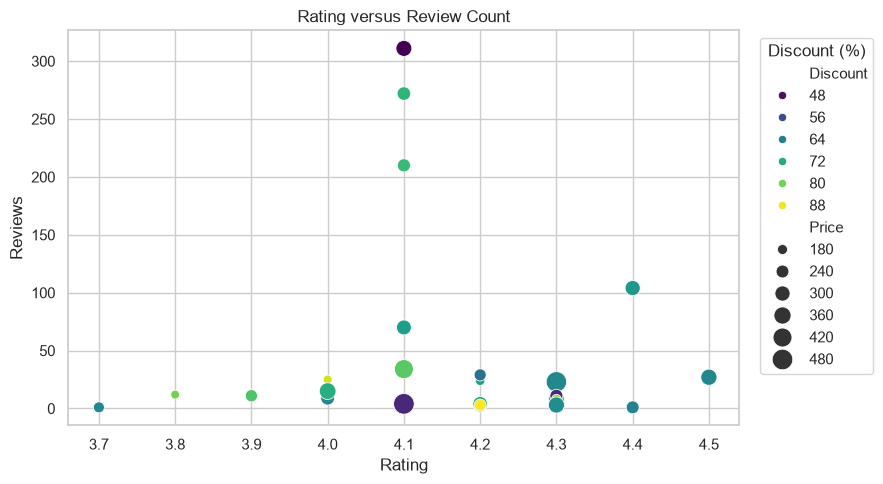

In [6]:
# Chart 4: Rating versus review count
scatter_df = df.dropna(subset=["Rating", "Reviews"])
plt.figure(figsize=(9, 5))
sns.scatterplot(data=scatter_df, x="Rating", y="Reviews", hue="Discount", size="Price", sizes=(40, 220), palette="viridis")
plt.title("Rating versus Review Count")
plt.xlabel("Rating")
plt.ylabel("Reviews")
plt.legend(title="Discount (%)", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

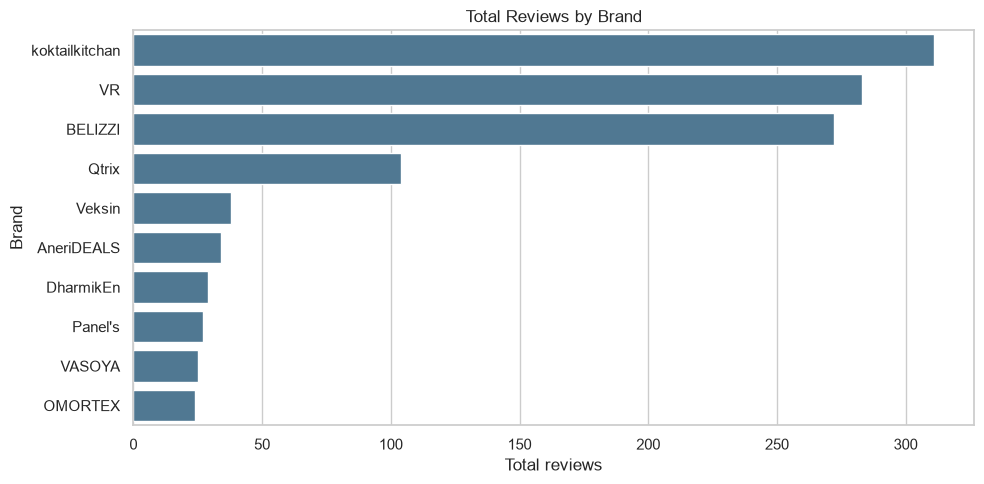

In [7]:
# Chart 5: Review count by brand
brand_reviews = (
    df.groupby("Brand", as_index=False)["Reviews"]
    .sum()
    .sort_values("Reviews", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_reviews, x="Reviews", y="Brand", color="#457b9d")
plt.title("Total Reviews by Brand")
plt.xlabel("Total reviews")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

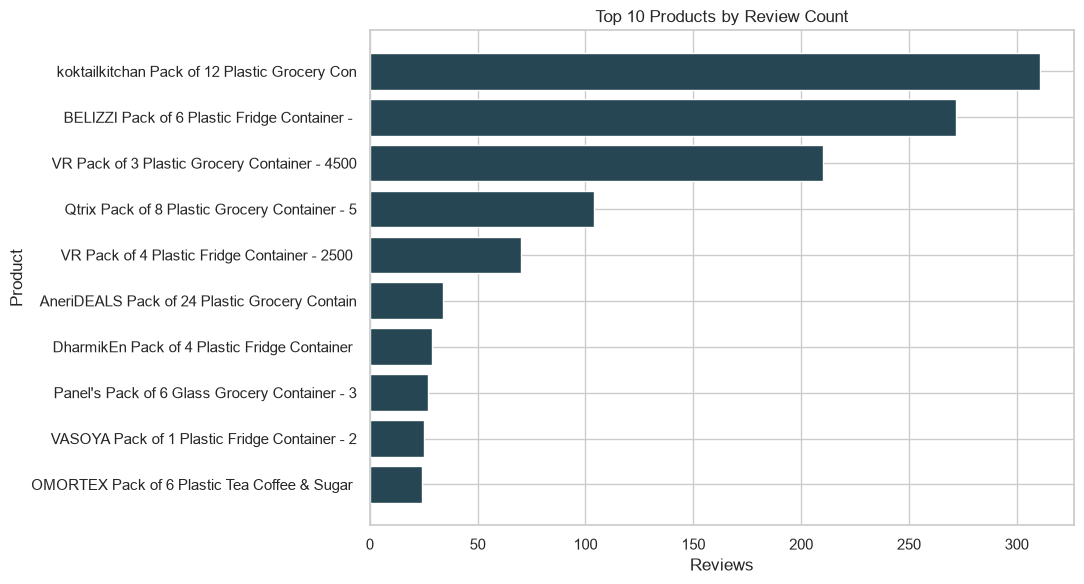

In [8]:
# Chart 6: Top products by review count
review_data = df.dropna(subset=["Reviews"]).nlargest(10, "Reviews").sort_values("Reviews")
plt.figure(figsize=(11, 6))
plt.barh(review_data["Product_Name"].str.slice(0, 45), review_data["Reviews"], color="#264653")
plt.title("Top 10 Products by Review Count")
plt.xlabel("Reviews")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

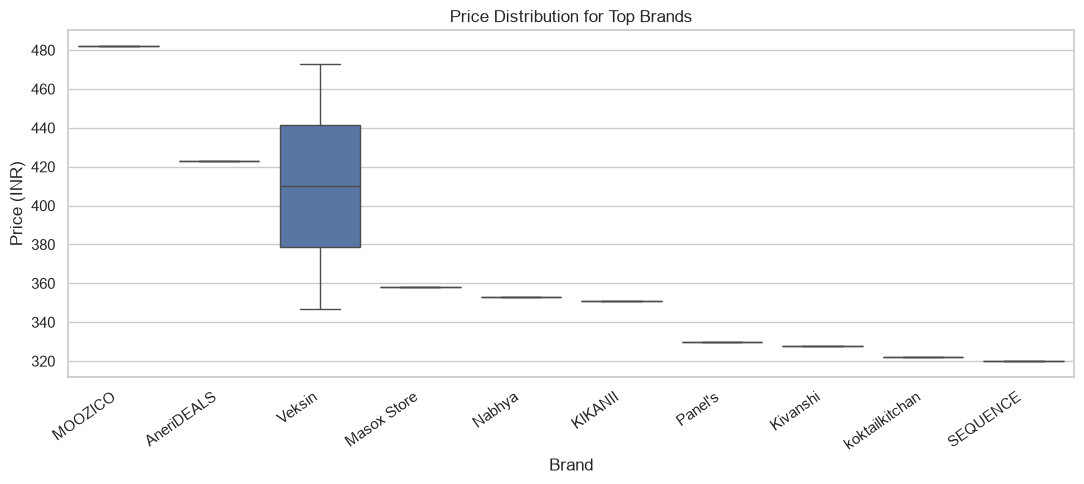

In [9]:
# Chart 7: Price distribution by brand
brand_order = df.groupby("Brand")["Price"].median().nlargest(10).index
plt.figure(figsize=(11, 5))
sns.boxplot(data=df[df["Brand"].isin(brand_order)], x="Brand", y="Price", order=brand_order)
plt.title("Price Distribution for Top Brands")
plt.xlabel("Brand")
plt.ylabel("Price (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

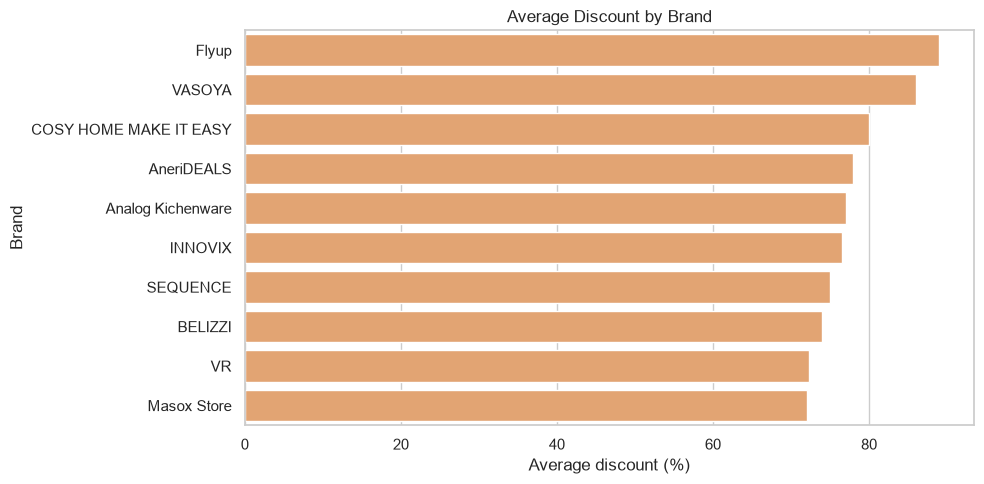

In [10]:
# Chart 8: Average discount by brand
brand_discount = (
    df.groupby("Brand", as_index=False)["Discount"]
    .mean()
    .sort_values("Discount", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 5))
sns.barplot(data=brand_discount, x="Discount", y="Brand", color="#f4a261")
plt.title("Average Discount by Brand")
plt.xlabel("Average discount (%)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

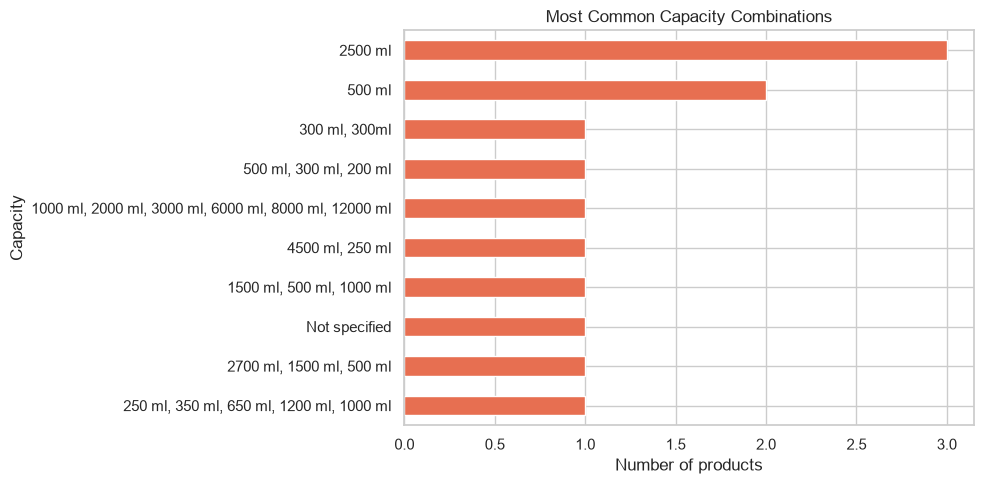

In [11]:
# Chart 9: Products by capacity label
capacity_counts = (
    df["Capacity"].fillna("Not specified").value_counts().head(10)
)
plt.figure(figsize=(10, 5))
capacity_counts.sort_values().plot(kind="barh", color="#e76f51")
plt.title("Most Common Capacity Combinations")
plt.xlabel("Number of products")
plt.ylabel("Capacity")
plt.tight_layout()
plt.show()

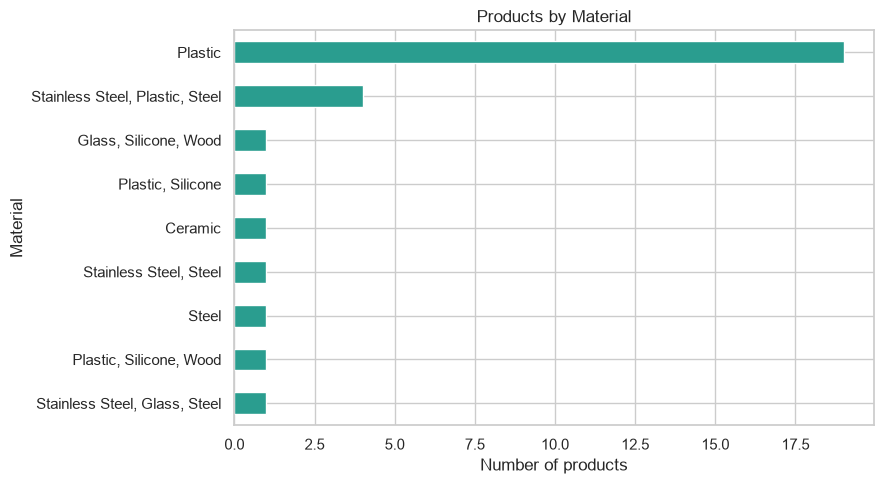

In [12]:
# Chart 10: Products by material
material_counts = df["Material"].value_counts().head(10)
plt.figure(figsize=(9, 5))
material_counts.sort_values().plot(kind="barh", color="#2a9d8f")
plt.title("Products by Material")
plt.xlabel("Number of products")
plt.ylabel("Material")
plt.tight_layout()
plt.show()